# 02 — Spectral Indices: NDVI, NDWI, and NDBI

This notebook inspects the **already generated** spectral-index GeoTIFFs for the Sentinel-2 study area. It checks raster metadata, masks nodata/non-finite values, summarizes distributions, and plots the indices side by side.

**Expected files:** `outputs/indices/ndvi.tif`, `outputs/indices/ndwi.tif`, and `outputs/indices/ndbi.tif`.

**Important:** this notebook does not recalculate or overwrite index rasters. The common formulas are NDVI = (B08 − B04)/(B08 + B04), green–NIR NDWI = (B03 − B08)/(B03 + B08), and NDBI = (B11 − B08)/(B11 + B08). Verify the generating script before interpreting results.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import plotting_extent

# Support launching Jupyter from the repository root or notebooks/.
CWD = Path.cwd().resolve()
if (CWD / "outputs").is_dir() and (CWD / "data").is_dir():
    PROJECT_ROOT = CWD
elif CWD.name.lower() == "notebooks" and (CWD.parent / "outputs").is_dir():
    PROJECT_ROOT = CWD.parent
else:
    raise FileNotFoundError("Start Jupyter from the repository root or its notebooks/ folder.")

INDEX_DIR = PROJECT_ROOT / "outputs" / "indices"
INDEX_PATHS = {
    "NDVI": INDEX_DIR / "ndvi.tif",
    "NDWI": INDEX_DIR / "ndwi.tif",
    "NDBI": INDEX_DIR / "ndbi.tif",
}
print("Project root:", PROJECT_ROOT)
print("Index directory:", INDEX_DIR)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Rasterio:", rasterio.__version__)


Project root: C:\Users\lenovo\Desktop\satellite-land-cover-classification
Index directory: C:\Users\lenovo\Desktop\satellite-land-cover-classification\outputs\indices
NumPy: 2.5.3
Pandas: 3.0.6
Rasterio: 1.5.2


## 1. Inspect raster metadata and grid alignment

Before comparing index rasters pixel by pixel, verify that they share the same CRS, dimensions, transform, and bounds. Matching array shapes alone do not establish spatial alignment.


In [2]:
metadata_rows = []
missing_files = []
for name, path in INDEX_PATHS.items():
    if not path.exists():
        missing_files.append(str(path.relative_to(PROJECT_ROOT)))
        continue
    with rasterio.open(path) as src:
        metadata_rows.append({
            "index": name,
            "path": str(path.relative_to(PROJECT_ROOT)),
            "width": src.width, "height": src.height, "bands": src.count,
            "crs": str(src.crs) if src.crs else None,
            "resolution_x": src.res[0], "resolution_y": src.res[1],
            "bounds": tuple(src.bounds), "nodata": src.nodata,
            "dtype": src.dtypes[0], "transform": tuple(src.transform),
        })

if missing_files:
    raise FileNotFoundError("Required index raster(s) missing:\n" + "\n".join(missing_files))

metadata_df = pd.DataFrame(metadata_rows)
display(metadata_df.drop(columns=["transform", "bounds"]))
reference = metadata_rows[0]
alignment_checks = []
for row in metadata_rows:
    alignment_checks.append({
        "index": row["index"],
        "same_crs_as_NDVI": row["crs"] == reference["crs"],
        "same_shape_as_NDVI": (row["width"], row["height"]) == (reference["width"], reference["height"]),
        "same_transform_as_NDVI": np.allclose(row["transform"], reference["transform"]),
        "same_bounds_as_NDVI": np.allclose(row["bounds"], reference["bounds"]),
    })
alignment_df = pd.DataFrame(alignment_checks)
display(alignment_df)
grids_aligned = bool(alignment_df.drop(columns="index").all().all())
if not grids_aligned:
    print("WARNING: one or more rasters are not aligned. Do not compare corresponding pixels until alignment is resolved.")
else:
    print("All three index rasters have matching grid metadata.")


,index,path,width,height,bands,crs,resolution_x,resolution_y,nodata,dtype
0,NDVI,outputs\indices\ndvi.tif,528,280,1,EPSG:32642,10.0,10.0,NaN,float32
1,NDWI,outputs\indices\ndwi.tif,528,280,1,EPSG:32642,10.0,10.0,NaN,float32
2,NDBI,outputs\indices\ndbi.tif,528,280,1,EPSG:32642,10.0,10.0,NaN,float32


,index,same_crs_as_NDVI,same_shape_as_NDVI,same_transform_as_NDVI,same_bounds_as_NDVI
0,NDVI,True,True,True,True
1,NDWI,True,True,True,True
2,NDBI,True,True,True,True


All three index rasters have matching grid metadata.


## 2. Load masked index arrays

Rasterio's masked read respects each file's nodata mask. Non-finite values are also masked. The original GeoTIFFs remain unchanged.


In [3]:
index_arrays, index_extents, index_crs = {}, {}, {}
for name, path in INDEX_PATHS.items():
    with rasterio.open(path) as src:
        band = src.read(1, masked=True).astype("float64")
        raw = np.asarray(band.filled(np.nan))
        mask = np.ma.getmaskarray(band) | ~np.isfinite(raw)
        index_arrays[name] = np.ma.array(raw, mask=mask)
        index_extents[name] = plotting_extent(src)
        index_crs[name] = str(src.crs) if src.crs else None

print("Array shapes:", {name: arr.shape for name, arr in index_arrays.items()})
if not grids_aligned:
    print("Warning: do not use pixel-by-pixel comparisons until all rasters are aligned.")
else:
    print("Metadata supports pixel-wise comparison; this does not validate index semantics or labels.")


Array shapes: {'NDVI': (280, 528), 'NDWI': (280, 528), 'NDBI': (280, 528)}
Metadata supports pixel-wise comparison; this does not validate index semantics or labels.


## 3. Summary statistics

Normalized-difference indices are often near −1 to +1. Out-of-range values may indicate unexpected inputs or processing issues, so this notebook reports them rather than clipping them.


In [4]:
summary_rows = []
for name, arr in index_arrays.items():
    valid = arr.compressed()
    if valid.size == 0:
        summary_rows.append({"index": name, "valid_pixels": 0, "masked_pixels": arr.size,
                             "min": np.nan, "p02": np.nan, "median": np.nan, "mean": np.nan,
                             "p98": np.nan, "max": np.nan, "outside_minus1_plus1": 0})
        continue
    summary_rows.append({
        "index": name, "valid_pixels": int(valid.size), "masked_pixels": int(arr.size-valid.size),
        "min": float(valid.min()), "p02": float(np.percentile(valid, 2)),
        "median": float(np.median(valid)), "mean": float(np.mean(valid)),
        "p98": float(np.percentile(valid, 98)), "max": float(valid.max()),
        "outside_minus1_plus1": int(np.count_nonzero((valid < -1) | (valid > 1))),
    })
index_summary = pd.DataFrame(summary_rows).set_index("index")
display(index_summary.round(5))
print("These statistics describe the stored rasters, not independent classification accuracy.")


,valid_pixels,masked_pixels,min,p02,median,mean,p98,max,outside_minus1_plus1
index,,,,,,,,,
NDVI,136126,11714,-0.23194,0.03543,0.37761,0.34890,0.59024,0.69071,0
NDWI,136126,11714,-0.61917,-0.51783,-0.36683,-0.34148,-0.06548,0.20268,0
NDBI,136126,11714,-0.43563,-0.26431,-0.07851,-0.07834,0.11632,0.31890,0


These statistics describe the stored rasters, not independent classification accuracy.


## 4. Visualize the three indices

Each panel uses its own 2nd–98th percentile display stretch to show spatial variation. Colours are therefore **not directly comparable between panels**; the underlying values are not changed.


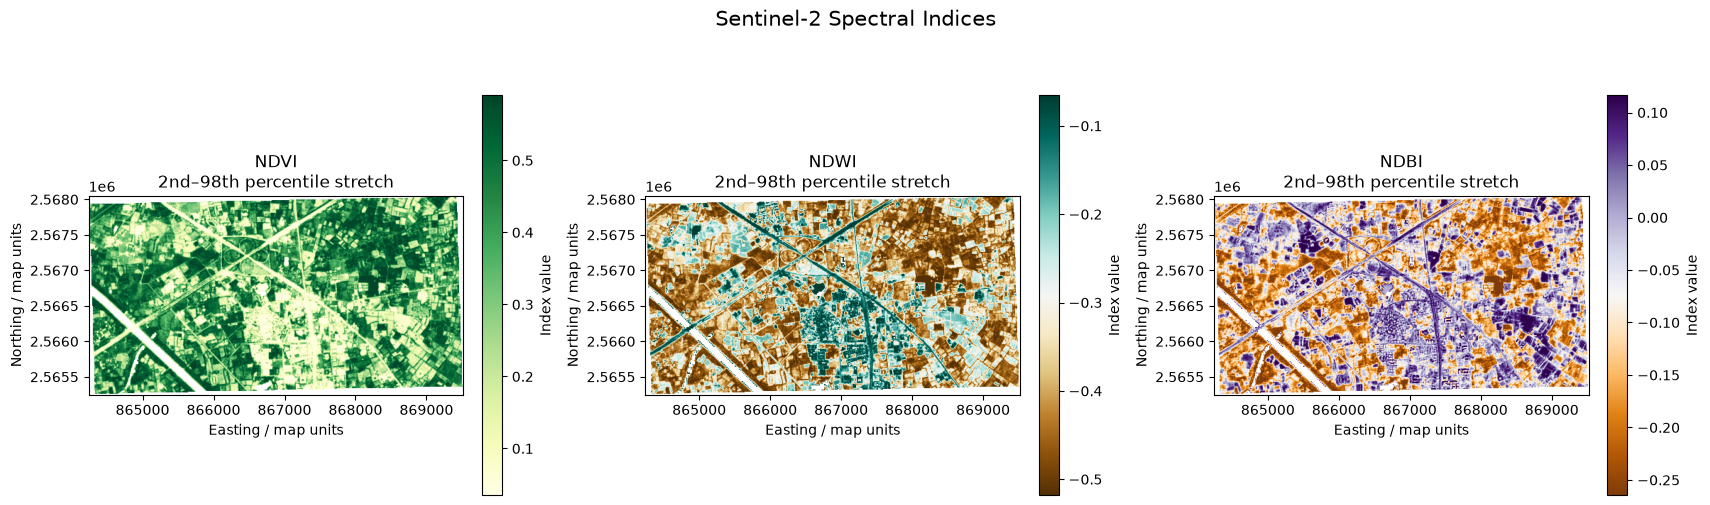

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), constrained_layout=True)
cmaps = {"NDVI": "YlGn", "NDWI": "BrBG", "NDBI": "PuOr"}
for ax, name in zip(axes, ["NDVI", "NDWI", "NDBI"]):
    arr = index_arrays[name]
    valid = arr.compressed()
    if not valid.size:
        ax.set_title(f"{name} (no valid pixels)")
        ax.axis("off")
        continue
    vmin, vmax = np.percentile(valid, [2, 98])
    if np.isclose(vmin, vmax):
        vmin, vmax = float(valid.min()), float(valid.max())
        if np.isclose(vmin, vmax):
            vmax = vmin + 1e-6
    im = ax.imshow(arr, cmap=cmaps[name], vmin=vmin, vmax=vmax,
                   extent=index_extents[name], origin="upper")
    ax.set_title(f"{name}\n2nd–98th percentile stretch")
    ax.set_xlabel("Easting / map units")
    ax.set_ylabel("Northing / map units")
    fig.colorbar(im, ax=ax, shrink=0.78, label="Index value")
fig.suptitle("Sentinel-2 Spectral Indices", fontsize=15)
plt.show()


## 5. Compare index distributions

Histograms help identify skew and unusual tails. They do not, by themselves, determine correct thresholds for vegetation, water, or built-up land.


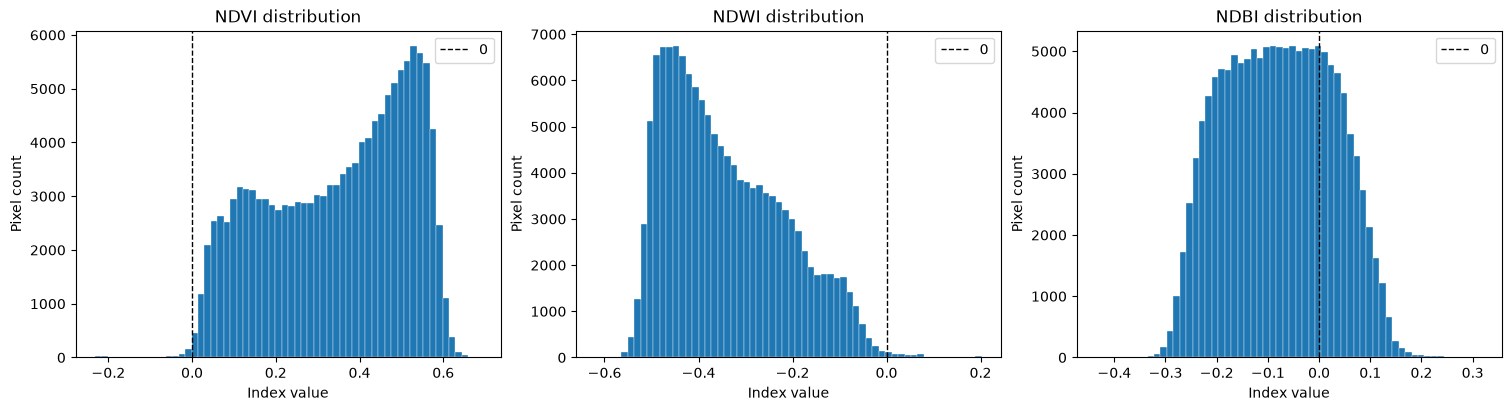

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, name in zip(axes, ["NDVI", "NDWI", "NDBI"]):
    values = index_arrays[name].compressed()
    if values.size:
        ax.hist(values, bins=60, edgecolor="white", linewidth=0.25)
        ax.axvline(0, color="black", linestyle="--", linewidth=1, label="0")
        ax.legend()
    ax.set_title(f"{name} distribution")
    ax.set_xlabel("Index value")
    ax.set_ylabel("Pixel count")
plt.show()


## 6. Interpretation guide and limitations

- **NDVI = (NIR − Red)/(NIR + Red):** higher values often correspond to greener vegetation.
- **NDWI (Green–NIR form) = (Green − NIR)/(Green + NIR):** can highlight open water, but shadows, wet soil, built surfaces, and mixed pixels can also affect values. Other indices also use the name NDWI, so state the formula used.
- **NDBI = (SWIR − NIR)/(SWIR + NIR):** can highlight some built-up surfaces, but bare soil may also have high values.

### Resolution caveat
Sentinel-2 B03, B04, and B08 are native 10 m bands, while B11 is native 20 m. If NDBI is stored on a 10 m grid, verify how B11 was resampled and aligned. Resampling does not create new 10 m information.

### Quality caveat
Cloud, haze, shadow, and invalid pixels should be handled in the upstream workflow. This notebook respects masks stored in the index rasters; it does not independently apply the Sentinel-2 Scene Classification Layer (SCL).

### Next step
Use `03_training_data_analysis.ipynb` to inspect labelled samples and class distributions. Do not assign classes from a single index threshold without validating it against representative reference samples.
